In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# read master data
master_df = pd.read_csv(
    r"C:\Users\rohan\Downloads\master_data (1).csv",
    skipinitialspace=True,
    low_memory=False,
    parse_dates=['Datetime']
)

# Create a binary Rain indicator (1 = any rain, 0 = no rain)
master_df['Rain'] = (master_df['Precipitation (mm)'] > 0).astype(int)


Average demand (MW):
Rain
0    4665.981377
1    4547.324287
Name: Total Demand, dtype: float64


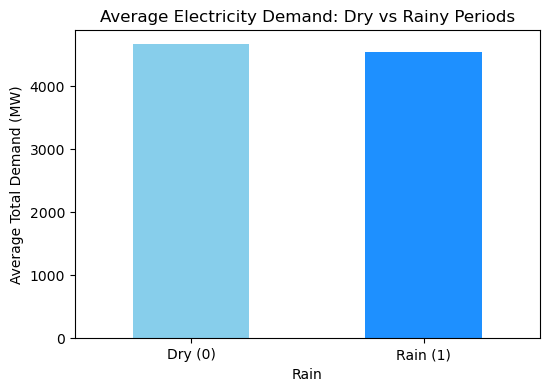

In [2]:
avg_demand = master_df.groupby("Rain")['Total Demand'].mean()
print("Average demand (MW):")
print(avg_demand)

plt.figure(figsize=(6,4))
avg_demand.plot(kind='bar', color=['skyblue', 'dodgerblue'])
plt.xticks([0,1], ['Dry (0)', 'Rain (1)'], rotation=0)
plt.ylabel("Average Total Demand (MW)")
plt.title("Average Electricity Demand: Dry vs Rainy Periods")
plt.show()



<Figure size 800x500 with 0 Axes>

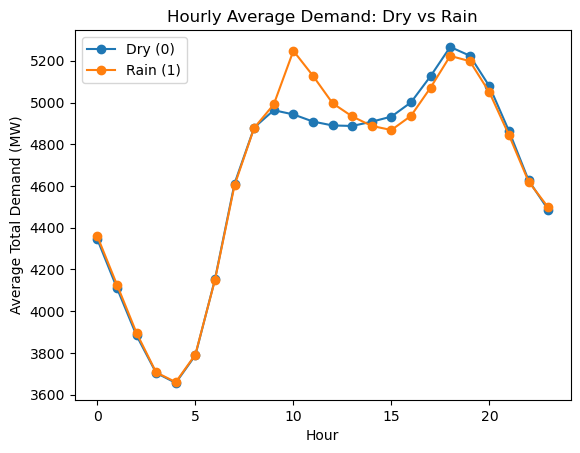

In [3]:
# --- By-hour comparison ---
master_df['Hour'] = master_df['Datetime'].dt.hour
hourly = master_df.groupby(['Hour','Rain'])['Total Demand'].mean().unstack()

plt.figure(figsize=(8,5))
hourly.plot(marker='o')
plt.ylabel("Average Total Demand (MW)")
plt.title("Hourly Average Demand: Dry vs Rain")
plt.legend(['Dry (0)', 'Rain (1)'])
plt.show()